In [17]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

In [18]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,
                           hypercube=False,class_sep=20)

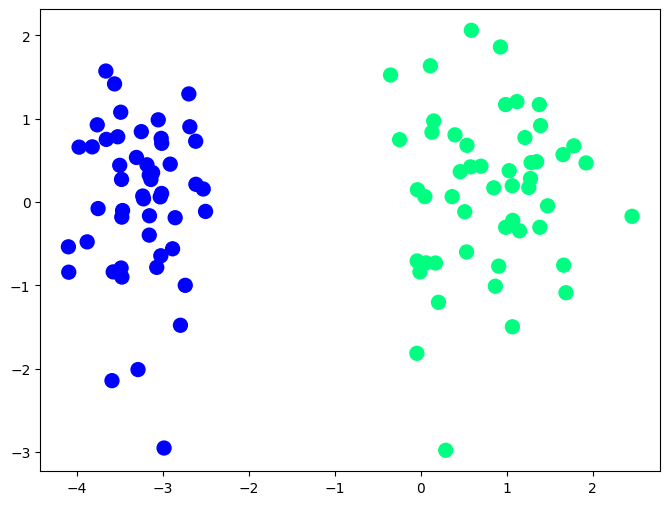

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.show()

In [31]:
model_log = LogisticRegression(penalty='none',solver='sag')
model_log.fit(X,y)

InvalidParameterError: The 'penalty' parameter of LogisticRegression must be a str among {'l1', 'l2', 'elasticnet'} or None. Got 'none' instead.

In [22]:
m = -(model_log.coef_[0][0]/model_log.coef_[0][1])
b = -(model_log.intercept_/model_log.coef_[0][1])

In [23]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

In [24]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [28]:
def gradient_Descent(X,y):
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5
    for i in range(5000):
        y_pred = sigmoid(np.dot(X,weights))
        weights = weights + lr*(np.dot((y-y_pred),X)/X.shape[0])
    return weights[0],weights[1:]

In [29]:
intercept_,coef_ = gradient_Descent(X,y)
m1 = -(coef_[0]/coef_[1])
b1 = -(intercept_/coef_[1])
x_input1 = np.linspace(-3,3,100)
y_input1 = m1*x_input1 + b1

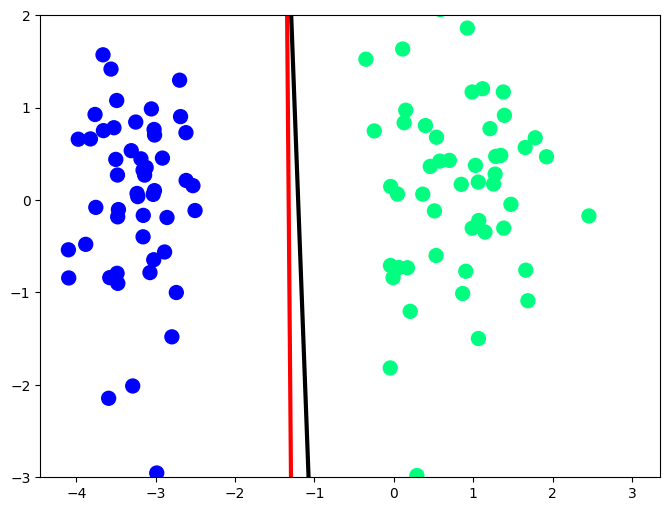

In [30]:
plt.figure(figsize=(8,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
plt.show()

#### Conclusion:
The slight difference is due to the penalty applied in scikit libraries.
